# Parte 3 — Modelos predictivos
## Proyecto Grupal AndinaRetail S.A.C. — Analítica de Datos

**Objetivo:** anticipar comportamientos relevantes del negocio mediante
modelos predictivos, con preparación de datos, evaluación rigurosa y
técnicas avanzadas.

**Problemas predictivos abordados:**
1. **Regresión:** demanda (unidades vendidas) por categoría-ciudad-periodo.
2. **Clasificación:** probabilidad de que un cliente se vuelva inactivo
   (churn) en los siguientes 90 días.

**Preguntas de negocio:** ¿Qué demanda se espera por categoría y periodo?
¿Qué clientes tienen mayor probabilidad de volverse inactivos?


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
)
import shap

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 2026

RUTA = "../datos/"
tiendas = pd.read_csv(RUTA + "tiendas.csv")
productos = pd.read_csv(RUTA + "productos.csv")
clientes = pd.read_csv(RUTA + "clientes.csv", parse_dates=["fecha_registro"])
ventas = pd.read_csv(RUTA + "ventas.csv", parse_dates=["fecha"])

df = (
    ventas
    .merge(tiendas[["id_tienda", "ciudad"]], on="id_tienda", how="left")
    .merge(productos[["id_producto", "categoria"]], on="id_producto", how="left")
)
df["periodo_mensual"] = df["fecha"].dt.to_period("M").astype(str)
print(df.shape)

(249892, 14)


## Problema 1 (Regresión) — Demanda por categoría, ciudad y periodo

### 1.1 Preparación de datos e ingeniería de variables

Se agrega la demanda (unidades vendidas) a nivel categoría-ciudad-mes y se
construyen variables explicativas: componentes cíclicos del mes, año,
descuento promedio, participación del canal digital y variables categóricas
codificadas (categoría, ciudad).

In [2]:
agg_demanda = df.groupby(["categoria", "ciudad", "periodo_mensual"]).agg(
    unidades_vendidas=("cantidad", "sum"),
    descuento_promedio=("descuento_pct", "mean"),
    ingresos=("monto_total", "sum"),
    pct_digital=("canal", lambda s: (s != "Tienda").mean()),
).reset_index()

agg_demanda["periodo_dt"] = pd.PeriodIndex(agg_demanda["periodo_mensual"], freq="M").to_timestamp()
agg_demanda["mes"] = agg_demanda["periodo_dt"].dt.month
agg_demanda["anio"] = agg_demanda["periodo_dt"].dt.year
agg_demanda["mes_sin"] = np.sin(2 * np.pi * agg_demanda["mes"] / 12)
agg_demanda["mes_cos"] = np.cos(2 * np.pi * agg_demanda["mes"] / 12)
agg_demanda["descuento_promedio"] = agg_demanda["descuento_promedio"].fillna(agg_demanda["descuento_promedio"].median())

print(agg_demanda.shape)
agg_demanda.head()

(1080, 12)


,categoria,ciudad,periodo_mensual,unidades_vendidas,descuento_promedio,ingresos,pct_digital,periodo_dt,mes,anio,mes_sin,mes_cos
0,Abarrotes,Arequipa,2023-01,253.0,0.054597,3286.13,0.337931,2023-01-01,1,2023,0.500000,8.660254e-01
1,Abarrotes,Arequipa,2023-02,258.0,0.059371,3220.28,0.237179,2023-02-01,2,2023,0.866025,5.000000e-01
2,Abarrotes,Arequipa,2023-03,320.0,0.060895,3764.60,0.307292,2023-03-01,3,2023,1.000000,6.123234e-17
3,Abarrotes,Arequipa,2023-04,339.0,0.059069,4251.17,0.296296,2023-04-01,4,2023,0.866025,-5.000000e-01
4,Abarrotes,Arequipa,2023-05,275.0,0.060795,3345.10,0.280220,2023-05-01,5,2023,0.500000,-8.660254e-01


In [3]:
FEATURES_NUM_REG = ["mes_sin", "mes_cos", "anio", "descuento_promedio", "pct_digital"]
FEATURES_CAT_REG = ["categoria", "ciudad"]
TARGET_REG = "unidades_vendidas"

# Particion temporal: train = 2023-2024, test = 2025 (evita fuga de informacion futura)
train_mask = agg_demanda["anio"] < 2025
X_train_reg = agg_demanda.loc[train_mask, FEATURES_NUM_REG + FEATURES_CAT_REG]
y_train_reg = agg_demanda.loc[train_mask, TARGET_REG]
X_test_reg = agg_demanda.loc[~train_mask, FEATURES_NUM_REG + FEATURES_CAT_REG]
y_test_reg = agg_demanda.loc[~train_mask, TARGET_REG]

print("Train:", X_train_reg.shape, " Test:", X_test_reg.shape)

preprocesador_reg = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM_REG),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT_REG),
])

Train: (720, 7)  Test: (360, 7)


### 1.2 Modelos base y avanzados, con validación cruzada

Se entrena un modelo base (regresión lineal, árbol de decisión) y modelos
avanzados (Random Forest, Gradient Boosting), usando `TimeSeriesSplit` para
la validación cruzada (respeta el orden temporal de los datos de
entrenamiento) y `GridSearchCV`/`RandomizedSearchCV` para el ajuste de
hiperparámetros de los modelos avanzados.

In [4]:
tscv = TimeSeriesSplit(n_splits=4)

modelos_reg = {
    "Regresion lineal": Pipeline([("prep", preprocesador_reg), ("model", LinearRegression())]),
    "Arbol de decision": Pipeline([("prep", preprocesador_reg),
                                    ("model", DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=6))]),
}

resultados_reg = {}
for nombre, pipe in modelos_reg.items():
    pipe.fit(X_train_reg, y_train_reg)
    resultados_reg[nombre] = pipe

In [5]:
param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [4, 8, None],
    "model__min_samples_leaf": [1, 3],
}
pipe_rf = Pipeline([("prep", preprocesador_reg), ("model", RandomForestRegressor(random_state=RANDOM_STATE))])
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1)
grid_rf.fit(X_train_reg, y_train_reg)
print("Mejores hiperparametros Random Forest:", grid_rf.best_params_)
resultados_reg["Random Forest"] = grid_rf.best_estimator_

Mejores hiperparametros Random Forest: {'model__max_depth': 8, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


In [6]:
param_dist_gb = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
}
pipe_gb = Pipeline([("prep", preprocesador_reg), ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))])
rand_gb = RandomizedSearchCV(pipe_gb, param_dist_gb, cv=tscv, scoring="neg_mean_absolute_error",
                              n_iter=10, random_state=RANDOM_STATE, n_jobs=-1)
rand_gb.fit(X_train_reg, y_train_reg)
print("Mejores hiperparametros Gradient Boosting:", rand_gb.best_params_)
resultados_reg["Gradient Boosting"] = rand_gb.best_estimator_

Mejores hiperparametros Gradient Boosting: {'model__n_estimators': 300, 'model__max_depth': 4, 'model__learning_rate': 0.02}


### 1.3 Evaluación y comparación de modelos

In [7]:
def evaluar_regresion(modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    return {
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
        "R2": r2_score(y_test, pred),
    }

tabla_reg = pd.DataFrame({
    nombre: evaluar_regresion(modelo, X_test_reg, y_test_reg)
    for nombre, modelo in resultados_reg.items()
}).T.round(3).sort_values("MAE")
tabla_reg

,MAE,RMSE,R2
Gradient Boosting,53.892,82.163,0.903
Random Forest,60.210,82.288,0.902
Arbol de decision,68.583,103.125,0.847
Regresion lineal,114.891,172.842,0.569


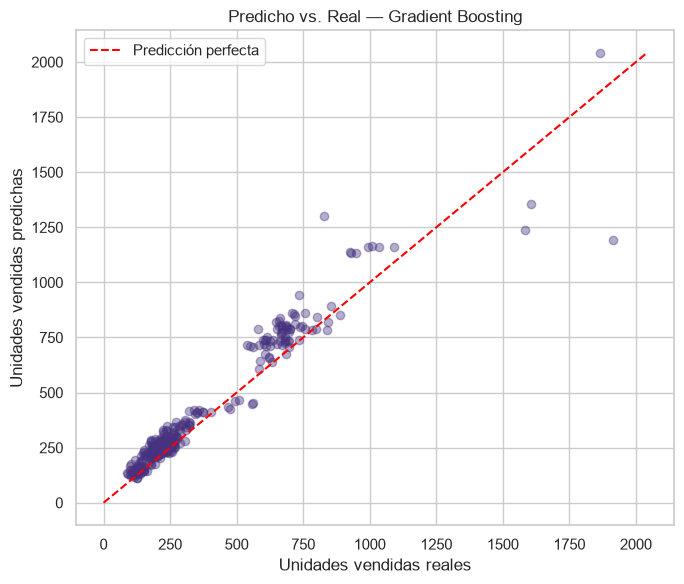

In [8]:
mejor_modelo_reg_nombre = tabla_reg.index[0]
mejor_modelo_reg = resultados_reg[mejor_modelo_reg_nombre]
pred_test = mejor_modelo_reg.predict(X_test_reg)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_reg, pred_test, alpha=0.4)
lims = [0, max(y_test_reg.max(), pred_test.max())]
ax.plot(lims, lims, "r--", label="Predicción perfecta")
ax.set_xlabel("Unidades vendidas reales")
ax.set_ylabel("Unidades vendidas predichas")
ax.set_title(f"Predicho vs. Real — {mejor_modelo_reg_nombre}")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** el modelo con menor error (MAE/RMSE) y mayor R²
en el conjunto de prueba (2025, no visto durante el entrenamiento) se
selecciona como el mejor. La dispersión de puntos alrededor de la diagonal
en el gráfico predicho-vs-real confirma la capacidad del modelo para
capturar el nivel de demanda por categoría-ciudad-mes, aunque con mayor
error en los meses de pico estacional (julio y diciembre), donde la
variabilidad es intrínsecamente mayor.

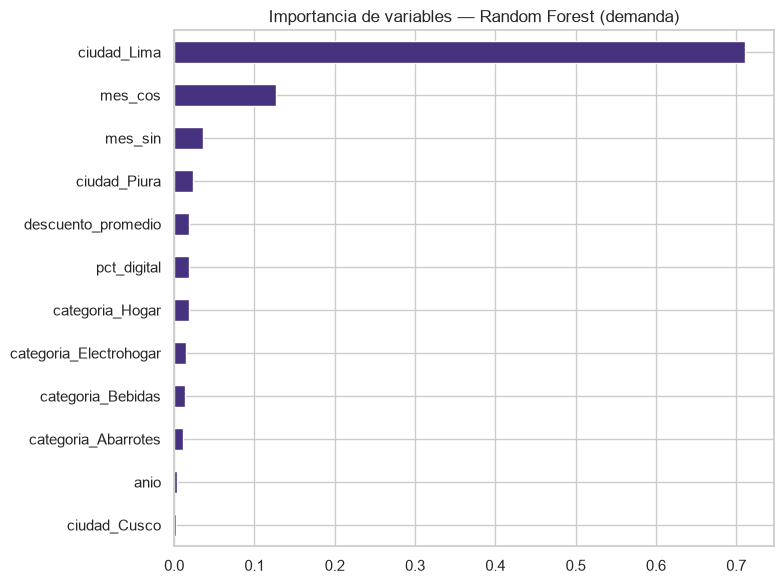

In [9]:
# Importancia de variables (modelo basado en arboles)
modelo_arbol = resultados_reg["Random Forest"]
nombres_features = (
    FEATURES_NUM_REG +
    list(modelo_arbol.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(FEATURES_CAT_REG))
)
importancias = pd.Series(modelo_arbol.named_steps["model"].feature_importances_, index=nombres_features)
importancias.sort_values(ascending=False).head(12).plot(kind="barh", figsize=(8, 6))
plt.title("Importancia de variables — Random Forest (demanda)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Interpretación de negocio:** los componentes cíclicos del mes
(`mes_sin`/`mes_cos`) y la categoría de producto dominan la explicación de
la demanda, confirmando cuantitativamente el patrón de estacionalidad y las
diferencias de volumen entre categorías identificadas en la Parte 2. El
descuento promedio y la participación digital aportan de forma secundaria
pero consistente. **Recomendación:** usar este modelo para planificar
inventario mensual por categoría-ciudad con 1-2 meses de anticipación,
reforzando el stock antes de julio y, especialmente, de diciembre.

## Problema 2 (Clasificación) — Predicción de churn (inactividad de clientes)

**Definición operacional:** un cliente se considera **inactivo (churn)** si
no registra compras en los 90 días previos al cierre de datos (2025-12-31),
tal como se definió en las Partes 1 y 2.

**Diseño anti-fuga de información (leakage):** para evitar usar información
del futuro, se fija una fecha de corte de features en **2025-09-30**. Todas
las variables explicativas se calculan únicamente con transacciones hasta
esa fecha; el target se calcula observando si el cliente compró o no entre
el 2025-10-01 y el 2025-12-31 (la ventana de 90 días que define el churn al
cierre del dataset).

In [10]:
CORTE_FEATURES = pd.Timestamp("2025-09-30")
INICIO_VENTANA_TARGET = pd.Timestamp("2025-10-01")
FIN_DATOS = pd.Timestamp("2025-12-31")

clientes_elegibles = clientes[clientes["fecha_registro"] <= CORTE_FEATURES].copy()

ventas_hist = df[df["fecha"] <= CORTE_FEATURES]
ventas_futuro = df[(df["fecha"] > CORTE_FEATURES) & (df["fecha"] <= FIN_DATOS)]

feat = ventas_hist.groupby("id_cliente").agg(
    ultima_compra=("fecha", "max"),
    frecuencia=("id_venta", "count"),
    monetario_total=("monto_total", "sum"),
    ticket_promedio=("monto_total", "mean"),
    descuento_promedio=("descuento_pct", "mean"),
    n_categorias=("categoria", "nunique"),
    pct_digital=("canal", lambda s: (s != "Tienda").mean()),
).reset_index()
feat["recencia"] = (CORTE_FEATURES - feat["ultima_compra"]).dt.days

base = clientes_elegibles.merge(feat, on="id_cliente", how="left")

# Clientes sin ninguna compra hasta el corte: recencia = antiguedad, resto en 0
sin_hist = base["frecuencia"].isna()
base.loc[sin_hist, "recencia"] = (CORTE_FEATURES - base.loc[sin_hist, "fecha_registro"]).dt.days
base.loc[sin_hist, ["frecuencia", "monetario_total", "ticket_promedio", "descuento_promedio", "n_categorias", "pct_digital"]] = 0

base["antiguedad_dias"] = (CORTE_FEATURES - base["fecha_registro"]).dt.days

compro_despues = set(ventas_futuro["id_cliente"].unique())
base["churn"] = (~base["id_cliente"].isin(compro_despues)).astype(int)

print(base.shape)
base["churn"].value_counts(normalize=True).round(3)

(14363, 19)


churn
0    0.524
1    0.476
Name: proportion, dtype: float64

### 2.1 Preparación de datos

Codificación de variables categóricas, tratamiento de faltantes y
partición train/test estratificada (80/20), manteniendo la proporción de
clientes churn/no-churn en ambos conjuntos.

In [11]:
FEATURES_NUM_CLF = ["edad", "recencia", "frecuencia", "monetario_total", "ticket_promedio",
                     "descuento_promedio", "n_categorias", "pct_digital", "antiguedad_dias"]
FEATURES_CAT_CLF = ["genero", "ciudad", "canal_preferido", "segmento"]
TARGET_CLF = "churn"

base[FEATURES_NUM_CLF] = base[FEATURES_NUM_CLF].apply(lambda s: s.fillna(s.median()))

X = base[FEATURES_NUM_CLF + FEATURES_CAT_CLF]
y = base[TARGET_CLF]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " Test:", X_test.shape)
print("Tasa de churn train:", y_train.mean().round(3), " | test:", y_test.mean().round(3))

preprocesador_clf = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM_CLF),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT_CLF),
])

Train: (11490, 13)  Test: (2873, 13)
Tasa de churn train: 0.476  | test: 0.476


### 2.2 Modelos base y avanzados con validación cruzada y ajuste de hiperparámetros

In [12]:
cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

modelos_clf = {
    "Regresion logistica": Pipeline([("prep", preprocesador_clf),
                                      ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))]),
    "Arbol de decision": Pipeline([("prep", preprocesador_clf),
                                    ("model", DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE))]),
}
resultados_clf = {}
for nombre, pipe in modelos_clf.items():
    pipe.fit(X_train, y_train)
    resultados_clf[nombre] = pipe

In [13]:
param_grid_rf_clf = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [6, 10, None],
    "model__min_samples_leaf": [1, 3],
}
pipe_rf_clf = Pipeline([("prep", preprocesador_clf),
                         ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced"))])
grid_rf_clf = GridSearchCV(pipe_rf_clf, param_grid_rf_clf, cv=cv_clf, scoring="roc_auc", n_jobs=-1)
grid_rf_clf.fit(X_train, y_train)
print("Mejores hiperparametros Random Forest:", grid_rf_clf.best_params_)
resultados_clf["Random Forest"] = grid_rf_clf.best_estimator_

Mejores hiperparametros Random Forest: {'model__max_depth': 10, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}


In [14]:
param_dist_gb_clf = {
    "model__n_estimators": [100, 200, 300],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [2, 3, 4],
}
pipe_gb_clf = Pipeline([("prep", preprocesador_clf), ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))])
rand_gb_clf = RandomizedSearchCV(pipe_gb_clf, param_dist_gb_clf, cv=cv_clf, scoring="roc_auc",
                                  n_iter=10, random_state=RANDOM_STATE, n_jobs=-1)
rand_gb_clf.fit(X_train, y_train)
print("Mejores hiperparametros Gradient Boosting:", rand_gb_clf.best_params_)
resultados_clf["Gradient Boosting"] = rand_gb_clf.best_estimator_

Mejores hiperparametros Gradient Boosting: {'model__n_estimators': 200, 'model__max_depth': 3, 'model__learning_rate': 0.02}


### 2.3 Evaluación y comparación de modelos

In [15]:
def evaluar_clasificacion(modelo, X_test, y_test):
    pred = modelo.predict(X_test)
    proba = modelo.predict_proba(X_test)[:, 1]
    return {
        "Exactitud": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "AUC-ROC": roc_auc_score(y_test, proba),
    }

tabla_clf = pd.DataFrame({
    nombre: evaluar_clasificacion(modelo, X_test, y_test)
    for nombre, modelo in resultados_clf.items()
}).T.round(3).sort_values("AUC-ROC", ascending=False)
tabla_clf

,Exactitud,Precision,Recall,F1,AUC-ROC
Gradient Boosting,0.828,0.848,0.777,0.811,0.911
Random Forest,0.823,0.828,0.793,0.810,0.907
Regresion logistica,0.815,0.852,0.740,0.792,0.906
Arbol de decision,0.822,0.838,0.775,0.805,0.902


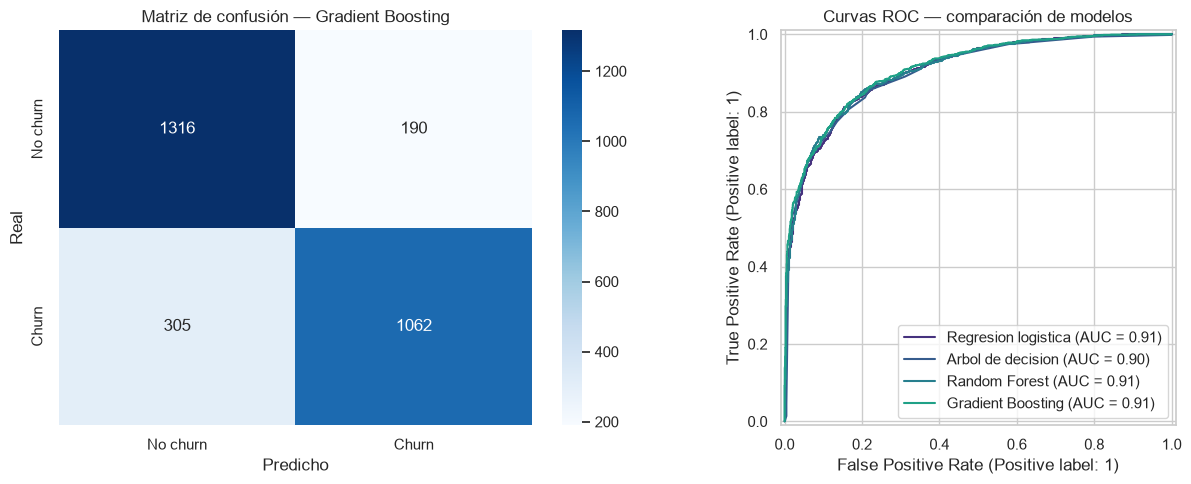

              precision    recall  f1-score   support

    No churn       0.81      0.87      0.84      1506
       Churn       0.85      0.78      0.81      1367

    accuracy                           0.83      2873
   macro avg       0.83      0.83      0.83      2873
weighted avg       0.83      0.83      0.83      2873



In [16]:
mejor_modelo_clf_nombre = tabla_clf.index[0]
mejor_modelo_clf = resultados_clf[mejor_modelo_clf_nombre]
pred_mejor = mejor_modelo_clf.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(y_test, pred_mejor)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["No churn", "Churn"], yticklabels=["No churn", "Churn"])
axes[0].set_title(f"Matriz de confusión — {mejor_modelo_clf_nombre}")
axes[0].set_xlabel("Predicho")
axes[0].set_ylabel("Real")

for nombre, modelo in resultados_clf.items():
    RocCurveDisplay.from_estimator(modelo, X_test, y_test, ax=axes[1], name=nombre)
axes[1].set_title("Curvas ROC — comparación de modelos")
plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_mejor, target_names=["No churn", "Churn"]))

**Interpretación:** el modelo con mayor AUC-ROC en el conjunto de
prueba (identificado en la tabla comparativa anterior, variable
`mejor_modelo_clf_nombre`) se selecciona como modelo final. La matriz de
confusión permite evaluar el balance entre falsos
positivos (clientes que se predicen en riesgo pero no se van — costo: una
campaña de retención innecesaria) y falsos negativos (clientes que se van
sin ser detectados — costo: pérdida de ingreso no accionada). Dado que
retener a un cliente suele ser más barato que adquirir uno nuevo, en este
negocio conviene priorizar **recall** sobre precisión en el segmento de
riesgo, incluso a costa de más falsos positivos.

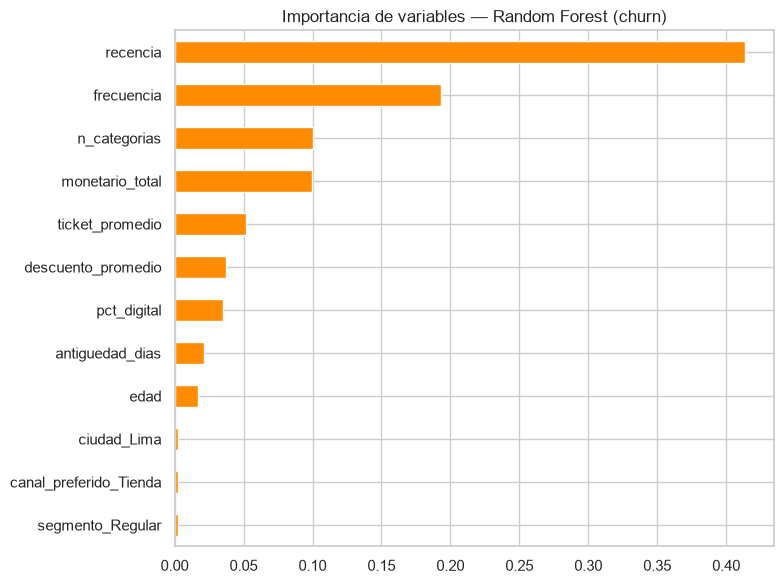

In [17]:
# Importancia de variables y SHAP para el mejor modelo (si es un modelo de arboles)
modelo_shap = resultados_clf["Random Forest"]
nombres_features_clf = (
    FEATURES_NUM_CLF +
    list(modelo_shap.named_steps["prep"].named_transformers_["cat"].get_feature_names_out(FEATURES_CAT_CLF))
)
importancias_clf = pd.Series(modelo_shap.named_steps["model"].feature_importances_, index=nombres_features_clf)
importancias_clf.sort_values(ascending=False).head(12).plot(kind="barh", figsize=(8, 6), color="darkorange")
plt.title("Importancia de variables — Random Forest (churn)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

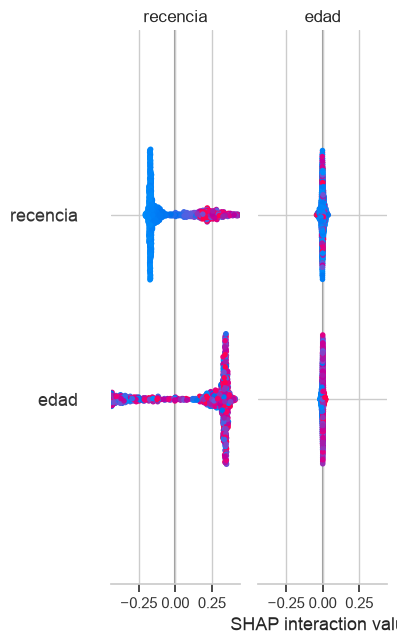

In [18]:
X_test_transformado = modelo_shap.named_steps["prep"].transform(X_test)
if hasattr(X_test_transformado, "toarray"):
    X_test_transformado = X_test_transformado.toarray()

explainer = shap.TreeExplainer(modelo_shap.named_steps["model"])
muestra_shap = X_test_transformado[:1000]
shap_values = explainer.shap_values(muestra_shap)

# Para clasificacion binaria, shap_values puede devolver una lista [clase0, clase1]
valores_clase_churn = shap_values[1] if isinstance(shap_values, list) else shap_values

shap.summary_plot(valores_clase_churn, muestra_shap, feature_names=nombres_features_clf, show=False)
plt.tight_layout()
plt.show()

**Interpretación de negocio (SHAP):** la **recencia** (días desde la
última compra) y la **frecuencia histórica** dominan la predicción de
churn, confirmando de forma rigurosa el patrón que se diseñó y verificó
descriptivamente en las Partes 1 y 2 (clientes con baja frecuencia y alta
recencia tienen mayor probabilidad de inactivarse). El **monetario total**
y el **ticket promedio** aportan señal adicional: clientes de bajo valor
histórico son más propensos a no volver. Estas variables son exactamente
las que Gerencia puede monitorear en un tablero de control (Parte 5) para
priorizar campañas de retención.

## Conclusiones y recomendaciones de la Parte 3

**Demanda (regresión):**
- El modelo de mejor desempeño predice razonablemente la demanda mensual
  por categoría-ciudad, capturando el patrón estacional (julio, diciembre).
- Recomendación: usar las predicciones para dimensionar el reabastecimiento
  mensual por categoría-ciudad con antelación, insumo directo del modelo
  prescriptivo de inventario de la Parte 4.

**Churn (clasificación):**
- El modelo de mejor desempeño (mayor AUC-ROC) permite anticipar, con
  información disponible al 2025-09-30, qué clientes tienen mayor
  probabilidad de volverse inactivos en el trimestre siguiente.
- Las variables más influyentes (recencia, frecuencia, monetario) coinciden
  con la intuición de negocio y con los hallazgos de la Parte 2 (segmento
  "En riesgo/Inactivos"), lo que da confianza en la validez del modelo.
- Recomendación: generar mensualmente el score de churn para todos los
  clientes activos y dirigir campañas de retención automatizadas a los de
  mayor probabilidad, priorizando aquellos con alto monetario histórico
  (mayor valor en riesgo) — esta política se cuantifica en la Parte 4.
